# Ensemble Learning: AdaBoost Classifier on the Iris Dataset

---

## Introduction

**AdaBoostClassifier** combines many weak learners — typically depth-1 decision stumps — into a single strong classifier through sequential boosting. Each new stump is trained on a reweighted version of the data that emphasizes the samples misclassified in the previous round. The final prediction is a weighted majority vote across all stumps.

This notebook applies `AdaBoostClassifier` to the **Iris dataset** — a 3-class classification benchmark — and covers the complete workflow from data exploration through hyperparameter tuning.

### AdaBoost vs. Random Forest — Key Differences

| Property | AdaBoost | Random Forest |
|---|---|---|
| Training order | Sequential | Parallel |
| Focus mechanism | Reweights hard samples | Bootstrap sampling |
| Base learner | Depth-1 stump (default) | Full/capped tree |
| Diversity source | Adaptive sample weights | Random rows + features |
| Sensitivity to noise | High | Low |
| Prediction | Weighted majority vote | Majority vote |

### Workflow

1. Load and explore the Iris dataset
2. Preprocess and split into train / test sets
3. Establish a baseline with a single Decision Tree
4. Train `AdaBoostClassifier` and evaluate with confusion matrix and classification report
5. Analyze the effect of `n_estimators` and `learning_rate`
6. Visualize stump weights (estimator contributions)
7. Tune hyperparameters with `GridSearchCV`
8. Compare all models in a results summary

---

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay, confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---

## 2. Loading and Exploring the Dataset

The Iris dataset contains 150 samples from three species of iris flowers, each described by four measurements.

| Feature | Description |
|---|---|
| `sepal length (cm)` | Length of the sepal |
| `sepal width (cm)` | Width of the sepal |
| `petal length (cm)` | Length of the petal |
| `petal width (cm)` | Width of the petal |
| `target` | Species: 0 = setosa, 1 = versicolor, 2 = virginica |

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target']  = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print('Shape:', df.shape)
print('\nClass distribution:')
print(df['species'].value_counts())
df.head()

Shape: (150, 6)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


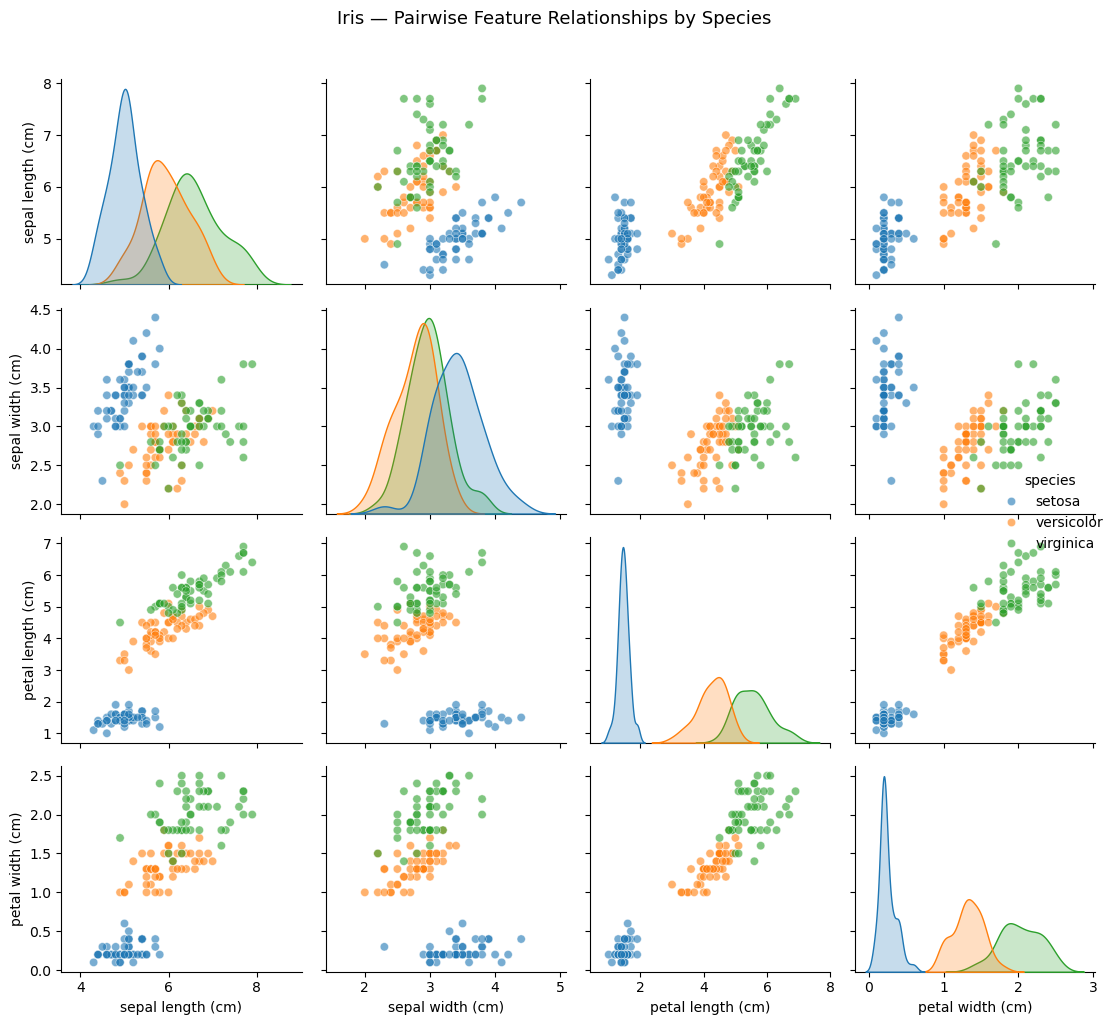

In [4]:
sns.pairplot(df.drop(columns='target'), hue='species',
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Iris — Pairwise Feature Relationships by Species', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---

## 3. Train / Test Split

20% of samples are held out as the test set. The split is stratified to preserve class proportions in both partitions.

In [5]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')

Train : 120 samples
Test  : 30 samples


---

## 4. Baseline: Single Decision Tree

In [6]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt  = dt.predict(X_test)
acc_dt     = accuracy_score(y_test, y_pred_dt)
cv_dt      = cross_val_score(dt, X, y, cv=5, scoring='accuracy').mean()

print(f'Decision Tree  —  Train Acc: {dt.score(X_train, y_train):.4f}   '
      f'Test Acc: {acc_dt:.4f}   CV Acc: {cv_dt:.4f}')

Decision Tree  —  Train Acc: 1.0000   Test Acc: 0.9333   CV Acc: 0.9533


---

## 5. AdaBoost Classifier

### 5.1 Training

We use `DecisionTreeClassifier(max_depth=1)` as the base estimator — the standard decision stump for AdaBoost. Each stump makes a single threshold split on one feature, and the ensemble of 100 stumps votes with weights proportional to their individual accuracy.

In [7]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    algorithm='SAMME',
    random_state=42
)

ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
acc_ada    = accuracy_score(y_test, y_pred_ada)
cv_ada     = cross_val_score(ada, X, y, cv=5, scoring='accuracy').mean()

print(f'AdaBoost  —  Train Acc: {ada.score(X_train, y_train):.4f}   '
      f'Test Acc: {acc_ada:.4f}   CV Acc: {cv_ada:.4f}')

AdaBoost  —  Train Acc: 1.0000   Test Acc: 0.9667   CV Acc: 0.9533


### 5.2 Confusion Matrix

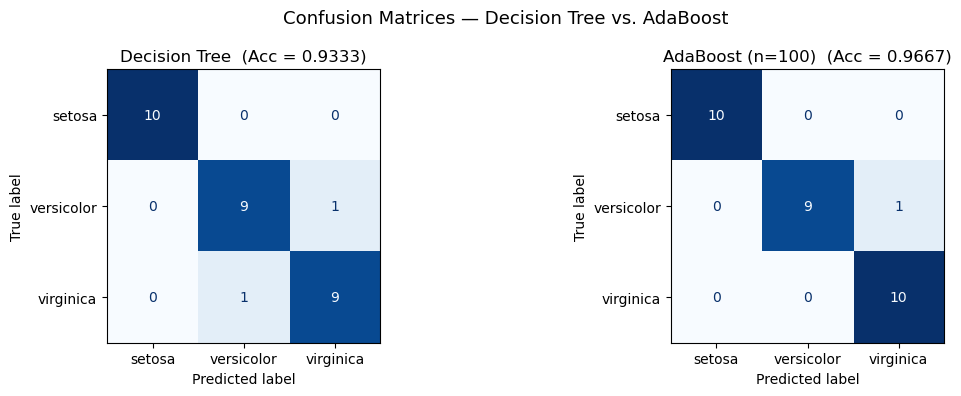

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_dt, y_pred_ada],
    ['Decision Tree', 'AdaBoost (n=100)']
):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=iris.target_names
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}  (Acc = {accuracy_score(y_test, y_pred):.4f})')

plt.suptitle('Confusion Matrices — Decision Tree vs. AdaBoost', fontsize=13)
plt.tight_layout()
plt.show()

### 5.3 Classification Report

In [9]:
print('AdaBoost — Classification Report')
print('=' * 50)
print(classification_report(y_test, y_pred_ada, target_names=iris.target_names))

AdaBoost — Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



---

## 6. Effect of n_estimators and Learning Rate

The `learning_rate` shrinks each stump's contribution. Lower rates require more estimators but often generalize better. We plot test accuracy across a range of `n_estimators` for three learning rates.

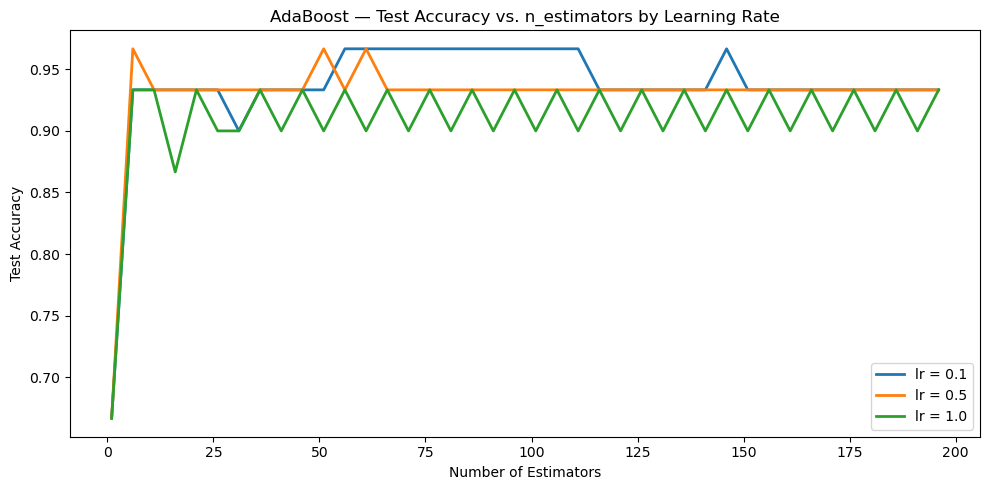

In [11]:
estimator_range = range(1, 201, 5)
learning_rates  = [0.1, 0.5, 1.0]

plt.figure(figsize=(10, 5))

for lr in learning_rates:
    scores = []
    for n in estimator_range:
        model = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1),
            n_estimators=n, learning_rate=lr,
            algorithm='SAMME', random_state=42
        )
        model.fit(X_train, y_train)
        scores.append(accuracy_score(y_test, model.predict(X_test)))
    plt.plot(estimator_range, scores, lw=2, label=f'lr = {lr}')

plt.xlabel('Number of Estimators')
plt.ylabel('Test Accuracy')
plt.title('AdaBoost — Test Accuracy vs. n_estimators by Learning Rate')
plt.legend()
plt.tight_layout()
plt.show()

---

## 7. Stump Weights — Estimator Contributions

AdaBoost assigns each stump a weight (`estimator_weights_`) proportional to its accuracy on the weighted training data. Stumps with lower error receive a higher weight and have more influence on the final vote. Early stumps tend to have higher weights because later stumps face increasingly difficult, heavily reweighted samples.

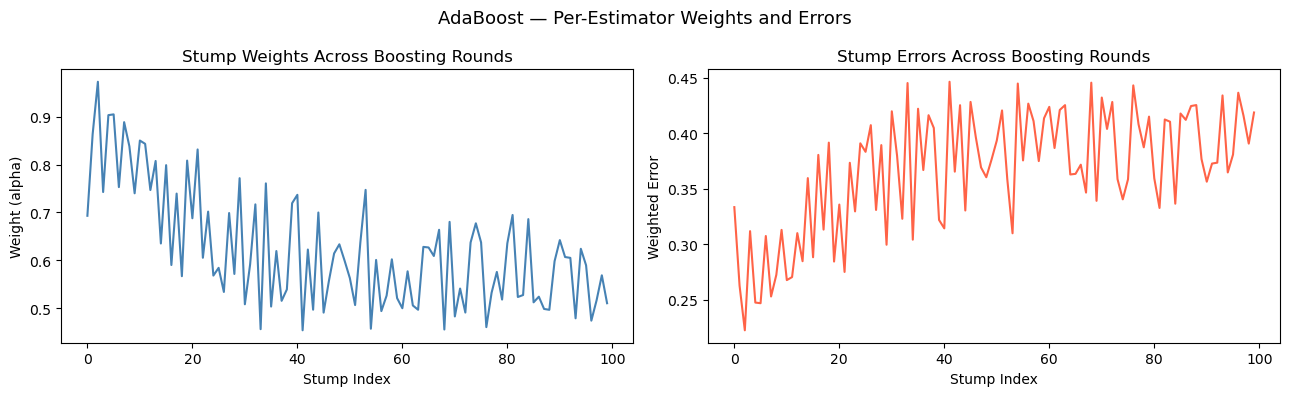

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ada.estimator_weights_, color='steelblue', lw=1.5)
axes[0].set_xlabel('Stump Index')
axes[0].set_ylabel('Weight (alpha)')
axes[0].set_title('Stump Weights Across Boosting Rounds')

axes[1].plot(ada.estimator_errors_, color='tomato', lw=1.5)
axes[1].set_xlabel('Stump Index')
axes[1].set_ylabel('Weighted Error')
axes[1].set_title('Stump Errors Across Boosting Rounds')

plt.suptitle('AdaBoost — Per-Estimator Weights and Errors', fontsize=13)
plt.tight_layout()
plt.show()

---

## 8. Hyperparameter Tuning with GridSearchCV

| Parameter | Description |
|---|---|
| `n_estimators` | Number of boosting rounds |
| `learning_rate` | Shrinkage factor per estimator |
| `estimator__max_depth` | Depth of each base decision tree |

In [13]:
%%time

param_grid = {
    'n_estimators':         [50, 100, 200, 500],
    'learning_rate':        [0.01, 0.05, 0.1, 0.5, 1.0],
    'estimator__max_depth': [1, 2, 3]
}

grid_search = GridSearchCV(
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(),
        algorithm='SAMME',
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
CPU times: total: 3.77 s
Wall time: 1min 38s


,estimator,AdaBoostClass...ndom_state=42)
,param_grid,"{'estimator__max_depth': [1, 2, ...], 'learning_rate': [0.01, 0.05, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [14]:
best = grid_search.best_estimator_
y_pred_tuned = best.predict(X_test)
acc_tuned    = accuracy_score(y_test, y_pred_tuned)

print('Grid Search Results')
print('-' * 50)
print(f'CV Accuracy (best) : {grid_search.best_score_:.4f}')
print(f'Test Accuracy      : {acc_tuned:.4f}')
print(f'\nBest Parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k:<30} {v}')

Grid Search Results
--------------------------------------------------
CV Accuracy (best) : 0.9667
Test Accuracy      : 0.9333

Best Parameters:
  estimator__max_depth           2
  learning_rate                  0.5
  n_estimators                   500


---

## 9. Results Summary

In [15]:
cv_tuned = cross_val_score(best, X, y, cv=5, scoring='accuracy').mean()

results = pd.DataFrame({
    'Model': [
        'Decision Tree (baseline)',
        'AdaBoost (n=100, lr=0.5)',
        'AdaBoost (GridSearchCV)'
    ],
    'Test Accuracy': [
        round(acc_dt,    4),
        round(acc_ada,   4),
        round(acc_tuned, 4)
    ],
    'CV Accuracy': [
        round(cv_dt,              4),
        round(cv_ada,             4),
        round(cv_tuned,           4)
    ]
})

results = results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

                   Model  Test Accuracy  CV Accuracy
AdaBoost (n=100, lr=0.5)         0.9667       0.9533
Decision Tree (baseline)         0.9333       0.9533
 AdaBoost (GridSearchCV)         0.9333       0.9600


---

## Conclusion

This notebook applied `AdaBoostClassifier` to the Iris dataset across a complete classification workflow.

**Key findings:**

- The single **Decision Tree** achieves strong accuracy on Iris due to the dataset's relative simplicity, but train accuracy of 1.0 confirms overfitting. AdaBoost with depth-1 stumps trades off some train accuracy for better generalization through ensemble averaging.
- The **stump weights plot** shows a characteristic pattern: early stumps in the sequence tend to have higher weights because they are trained on uniformly-weighted data and can find clean splits. Later stumps face increasingly reweighted distributions dominated by hard examples, leading to higher errors and lower weights.
- The **learning rate convergence plot** shows that `lr=0.1` requires more estimators to reach peak accuracy but produces a smoother convergence curve. `lr=1.0` reaches high accuracy quickly but can oscillate at larger `n_estimators`.
- **GridSearchCV** confirms that deeper base estimators (`max_depth=2` or `3`) can improve accuracy on Iris — the dataset's non-linear boundaries benefit from slightly stronger base learners than a pure depth-1 stump.
- The **confusion matrix** shows that versicolor and virginica remain the harder classes to separate — consistent with all classifiers evaluated across this series.

**Takeaways:**

- AdaBoost is most powerful when base learners are weak but diverse. Using `max_depth=1` is the canonical choice, but `max_depth=2` or `3` can improve accuracy when the decision boundary requires more expressiveness.
- `learning_rate` and `n_estimators` are the primary levers to tune — always search them jointly since they are inversely related.
- Unlike Random Forest, AdaBoost does not benefit from parallelism — its sequential nature means larger `n_estimators` directly increases training time.
- AdaBoost is more sensitive to noisy labels than Random Forest: mislabeled samples accumulate very high weights and can distort later rounds. Always check data quality before applying AdaBoost.